In [1]:
# Reference insulin level (dimensionless)
# At baseline glucose G=1.0, compute insulin secretion
h_ins = 3.4  # Insulin secretion Hill coefficient
C_ins = 2.3  # Insulin secretion threshold (relative to glucose)
I0 = abs(1.0)**h_ins / (abs(1.0)**h_ins + C_ins**h_ins)
I0

0.05562497765134089

In [2]:
def simple_inhibition(I,Ki):
    return 1 - I / (I + Ki)

def rescaled_inhibition(I,Ki):
    return  1- I / (I + Ki) / ( 1 / (1 + Ki) )


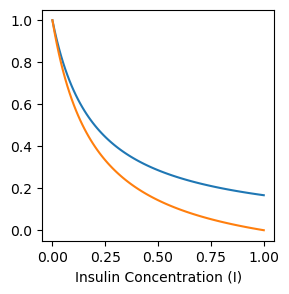

In [6]:
import numpy as np
import matplotlib.pyplot as plt

I_values = np.linspace(0,1,100)
Ki = 0.2 


simple_inh_values = simple_inhibition(I_values,Ki)
rescaled_inh_values = rescaled_inhibition(I_values,Ki)

f, ax = plt.subplots(figsize=(3,3))

plt.plot(I_values, simple_inh_values, label='Simple Inhibition')
plt.plot(I_values, rescaled_inh_values, label='Rescaled Inhibition')
plt.xlabel('Insulin Concentration (I)')
plt.show()

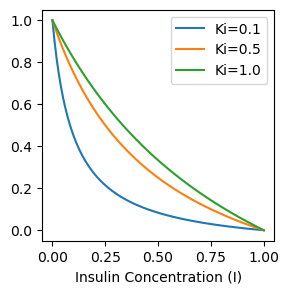

In [7]:
# Rescaled inhitbition at different Ki values
f, ax = plt.subplots(figsize=(3,3))
Ki_values = [0.1, 0.5, 1.0]
for Ki in Ki_values:
    rescaled_inh_values = rescaled_inhibition(I_values,Ki)
    plt.plot(I_values, rescaled_inh_values, label=f'Ki={Ki}')       
plt.xlabel('Insulin Concentration (I)')
plt.legend()

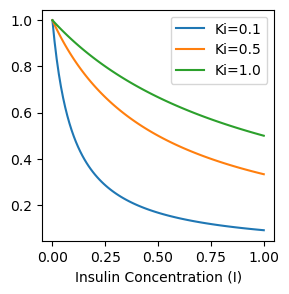

In [8]:
# Unscaled inhibition at different Ki values
f, ax = plt.subplots(figsize=(3,3))
Ki_values = [0.1, 0.5, 1.0]
for Ki in Ki_values:
    simple_inh_values = simple_inhibition(I_values,Ki)
    plt.plot(I_values, simple_inh_values, label=f'Ki={Ki}')       
plt.xlabel('Insulin Concentration (I)')
plt.legend()

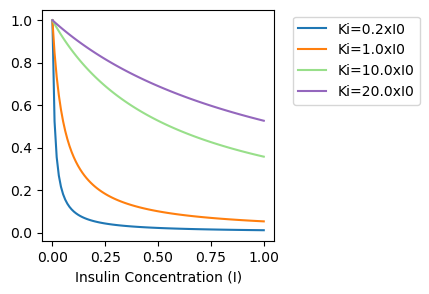

In [15]:
# Compare the different inhibition function for insulin with Ki = 0.2, 1.0, 10, 20 x I0 
f, ax = plt.subplots(figsize=(3,3))
Ki_values = [0.2*I0, 1.0*I0, 10.0*I0, 20.0*I0]

colors = plt.cm.tab20(np.linspace(0, 1, len(Ki_values)*2))

for i, Ki in enumerate(Ki_values):
    simple_inh_values = simple_inhibition(I_values,Ki)
    rescaled_inh_values = rescaled_inhibition(I_values,Ki)
    plt.plot(I_values, simple_inh_values, linestyle='-', color=colors[i], label=f'Ki={Ki/I0:.1f}xI0')
plt.xlabel('Insulin Concentration (I)')

# Legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()